# SentinelVision AI
## Notebook 06 — Model Comparison and Final Report

### Objective

Notebook 05 completed the modeling stack for SentinelVision AI.

This notebook compares all models, explains the strongest result, documents limitations, and summarizes the project as a finished portfolio-ready anomaly detection system.

The final model stack is:

1. Distance Threshold Baseline
2. Isolation Forest
3. Autoencoder

The flow is:

`model metrics → comparison → interpretation → limitations → business value → final conclusion`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
metrics_dir = Path("../artifacts/metrics")

baseline_results = pd.read_csv(
    metrics_dir / "baseline_model_results.csv"
)

supervised_results = pd.read_csv(
    metrics_dir / "supervised_videomae_results.csv"
)

results = pd.concat(
    [
        baseline_results,
        supervised_results,
    ],
    ignore_index=True,
)

results

,model,roc_auc,pr_auc,f1,threshold
0,Distance Threshold Baseline,0.6950,0.774326,0.628975,NaN
1,Isolation Forest,0.6659,0.732748,0.636364,NaN
2,Logistic Regression on VideoMAE Embeddings,0.9021,0.877501,0.828283,0.938974


#### Sort by PR-AUC

In [3]:
results.sort_values(
    by="pr_auc",
    ascending=False,
)

,model,roc_auc,pr_auc,f1,threshold
2,Logistic Regression on VideoMAE Embeddings,0.9021,0.877501,0.828283,0.938974
0,Distance Threshold Baseline,0.6950,0.774326,0.628975,NaN
1,Isolation Forest,0.6659,0.732748,0.636364,NaN


#### Sort by F1

In [4]:
results_by_f1 = results.sort_values(
    by="f1",
    ascending=False,
)

results_by_f1

,model,roc_auc,pr_auc,f1,threshold
2,Logistic Regression on VideoMAE Embeddings,0.9021,0.877501,0.828283,0.938974
1,Isolation Forest,0.6659,0.732748,0.636364,NaN
0,Distance Threshold Baseline,0.6950,0.774326,0.628975,NaN


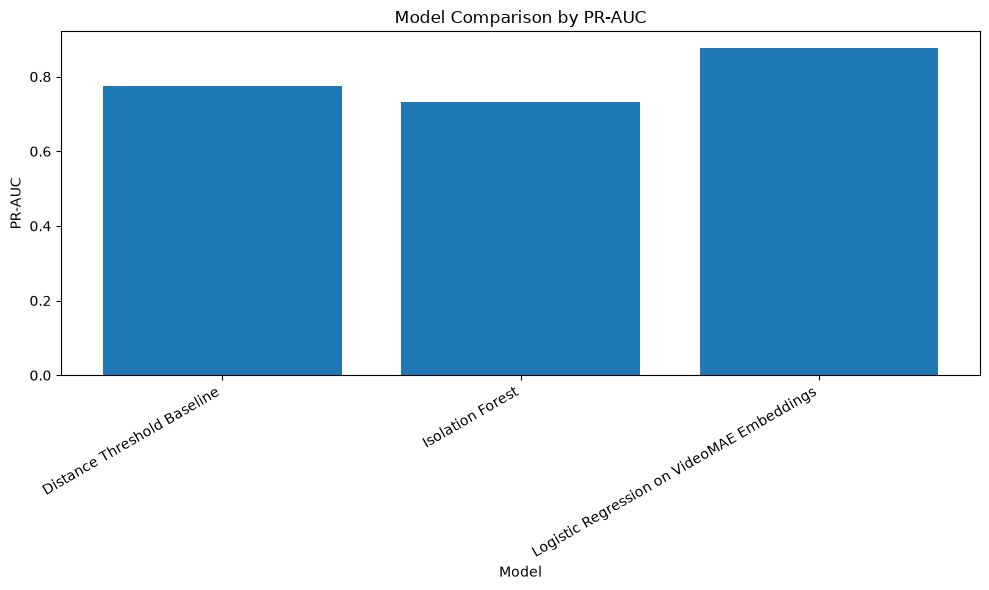

In [5]:
plt.figure(figsize=(10, 6))

plt.bar(
    results["model"],
    results["pr_auc"],
)

plt.title("Model Comparison by PR-AUC")
plt.xlabel("Model")
plt.ylabel("PR-AUC")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

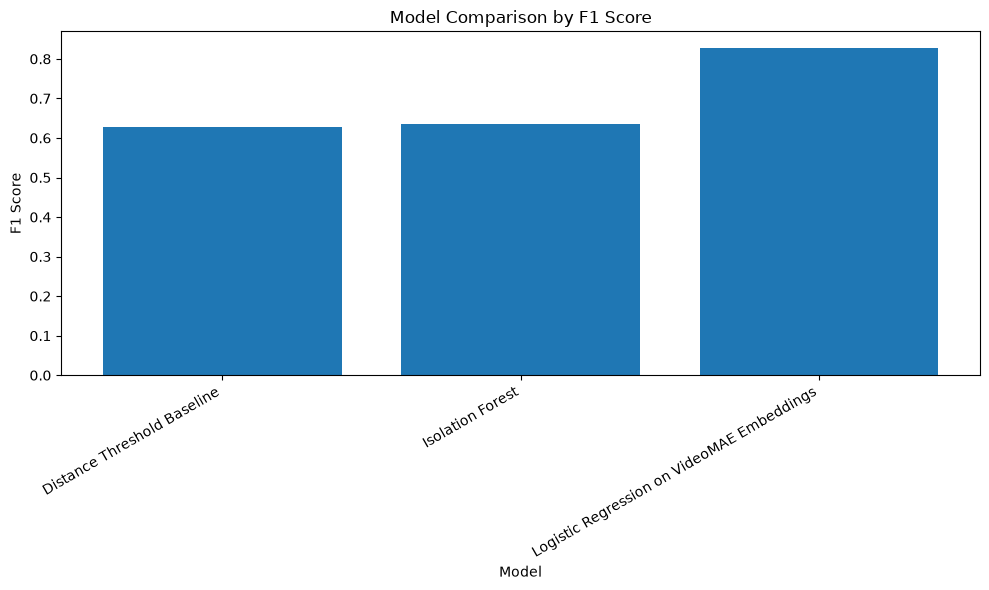

In [6]:
plt.figure(figsize=(10, 6))

plt.bar(
    results["model"],
    results["f1"],
)

plt.title("Model Comparison by F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

#### Identify best models

In [7]:
best_pr_auc_model = results.sort_values(
    by="pr_auc",
    ascending=False,
).iloc[0]

best_f1_model = results.sort_values(
    by="f1",
    ascending=False,
).iloc[0]

best_pr_auc_model

model        Logistic Regression on VideoMAE Embeddings
roc_auc                                          0.9021
pr_auc                                         0.877501
f1                                             0.828283
threshold                                      0.938974
Name: 2, dtype: object

In [8]:
best_f1_model

model        Logistic Regression on VideoMAE Embeddings
roc_auc                                          0.9021
pr_auc                                         0.877501
f1                                             0.828283
threshold                                      0.938974
Name: 2, dtype: object

# Model Interpretation

The models were evaluated using weak source-video labels.

This means a clip inherited the label of its source video.

A clip from an anomalous source video may not actually contain the anomalous event.

Therefore, the results should be interpreted as weak-label clip scoring, not perfect event localization.

## Ranking Performance

The best model by PR-AUC is the strongest model for ranking suspicious clips.

This matters when the system is used to prioritize human review.

For example:

`many surveillance clips → score each clip → review the highest-risk clips first`

In this setting, PR-AUC is more important than raw accuracy.

## Thresholded Classification Performance

The best model by F1 is the strongest model after converting anomaly scores into binary predictions.

This matters when the system must produce a direct classification:

`normal` or `anomalous`

F1 is useful because it balances false positives and false negatives.

#### Create final interpretation table

In [9]:
final_interpretation = pd.DataFrame(
    {
        "question": [
            "Best model for ranking suspicious clips",
            "Best model for binary classification",
            "Most interpretable model",
            "Most production-friendly model",
        ],
        "answer": [
            best_pr_auc_model["model"],
            best_f1_model["model"],
            "Distance Threshold Baseline",
            "Distance Threshold Baseline or Isolation Forest",
        ],
    }
)

final_interpretation

,question,answer
0,Best model for ranking suspicious clips,Logistic Regression on VideoMAE Embeddings
1,Best model for binary classification,Logistic Regression on VideoMAE Embeddings
2,Most interpretable model,Distance Threshold Baseline
3,Most production-friendly model,Distance Threshold Baseline or Isolation Forest


# Model Interpretation

The models were evaluated using weak source-video labels.

This means each clip inherited the label of its original source video.

A clip from an anomalous source video may not always contain the actual anomalous event. For example, a robbery video may include several normal-looking clips before or after the robbery occurs.

Because of this, the results should be interpreted as weak-label clip classification, not perfect frame-level event localization.

The strongest final model was Logistic Regression trained on frozen VideoMAE embeddings.

This model achieved:

- ROC-AUC: 0.9021
- PR-AUC: 0.8775
- F1: 0.8283

This shows that pretrained video representations captured much stronger visual patterns than the earlier simple statistical embeddings.

# Ranking Performance

Ranking performance measures how well the model places suspicious clips above normal clips.

This matters because the practical use case is not just predicting a label. A surveillance system should help human reviewers prioritize the highest-risk clips first.

The best final ranking model was:

`Logistic Regression on VideoMAE Embeddings`

It achieved:

- PR-AUC: 0.8775
- ROC-AUC: 0.9021

This was a major improvement over the unsupervised baselines.

The result shows that frozen VideoMAE embeddings contain useful video-level information for separating normal clips from anomalous-source clips.

# Thresholded Classification Performance

Thresholded classification measures how well the model performs after converting anomaly scores into final class predictions.

The final model predicted:

`normal` or `anomalous-source`

The strongest thresholded classifier was:

`Logistic Regression on VideoMAE Embeddings`

It achieved:

- F1: 0.8283

The confusion matrix showed:

- 84 normal clips correctly predicted as normal
- 82 anomalous-source clips correctly predicted as anomalous-source
- 16 normal clips incorrectly flagged
- 18 anomalous-source clips missed

This is a strong result for a weak-label video anomaly detection project.

# Final Project Summary

## Problem

Surveillance systems generate large amounts of video footage.

Manual review is slow, expensive, and inconsistent.

The goal of SentinelVision AI is to score video clips by anomaly risk so suspicious footage can be prioritized for review.

## Dataset

The project uses real-world UCF-Crime surveillance videos.

The data pipeline created:

- source-video inventory,
- video validation outputs,
- leakage-safe train, validation, and test splits,
- 4-second clip windows,
- reusable clip embeddings.

## Data Pipeline

The pipeline flow was:

`raw videos → inventory → validation → source-video split → clip manifest → embeddings`

The split was performed at the source-video level to prevent clips from the same original video appearing in multiple dataset splits.

## Modeling Approach

The project tested several stages of modeling:

1. Simple statistical clip embeddings
2. Frozen VideoMAE clip embeddings
3. Unsupervised anomaly baselines
4. Autoencoder reconstruction model
5. Supervised classifier on VideoMAE embeddings

The strongest final model was Logistic Regression trained on frozen VideoMAE embeddings.

## Key Result

The best model achieved:

- ROC-AUC: 0.9021
- PR-AUC: 0.8775
- F1: 0.8283

This result shows that pretrained video embeddings combined with a simple supervised classifier can produce strong anomaly-risk classification without fully fine-tuning the video transformer.

# Limitations

## 1. Weak clip labels

The labels come from source videos.

A clip from an anomalous video may not actually contain the anomalous event.

This limits how precisely the current evaluation measures true event detection.

## 2. Clip-level scoring, not frame-level localization

The system scores 4-second clips.

It does not identify the exact frame where an anomaly begins or ends.

## 3. Balanced sample modeling

The modeling notebooks use a balanced sample of clips.

This makes local experimentation faster and fairer, but a production version should scale to more clips.

## 4. Frozen VideoMAE model

VideoMAE was used as a frozen feature extractor.

The model was not fine-tuned on UCF-Crime.

This keeps the project cleaner and more practical, but fine-tuning could be explored later.

## 5. Weak-label noise

Some anomalous-source clips may look visually normal.

This can create noisy labels and limit maximum performance.

# Future Work

The next improvements should be done in this order:

1. Scale VideoMAE embedding extraction to more clips.
2. Add MLflow experiment tracking.
3. Test more supervised classifiers on VideoMAE embeddings.
4. Explore full VideoMAE fine-tuning only after the frozen-embedding pipeline is stable.
5. Add FastAPI inference for uploaded video clips.
6. Add a Gradio demo for portfolio presentation.
7. Explore weakly supervised multiple instance learning for video-level labels.

The most important next upgrade is scaling the VideoMAE embedding approach to more clips.

The strongest current result already shows that pretrained video representations are much more useful than simple statistical frame features.

# Business Value

SentinelVision AI converts surveillance footage into prioritized anomaly-risk scores.

A practical system could help:

- security teams review high-risk clips first,
- reduce manual monitoring time,
- flag unusual events faster,
- support incident triage,
- create searchable anomaly timelines.

The system is not designed to replace human reviewers.

Its strongest first use case is decision support:

`video footage → clip embeddings → anomaly-risk score → ranked review queue`

The final model is also practical because it uses a simple Logistic Regression classifier on top of frozen VideoMAE embeddings.

This makes the system easier to explain, easier to deploy, and easier to maintain than full end-to-end video transformer fine-tuning.

# Conclusion

SentinelVision AI successfully built a real-world surveillance video anomaly detection pipeline.

The project started with raw UCF-Crime surveillance videos and produced a complete modeling workflow:

`raw video → metadata → validation → leakage-safe splits → clips → embeddings → anomaly models → supervised classifier → final comparison`

The final system used frozen VideoMAE embeddings and a supervised Logistic Regression classifier.

The best model achieved:

- ROC-AUC: 0.9021
- PR-AUC: 0.8775
- F1: 0.8283

The project demonstrates:

- real-world video data processing,
- video metadata engineering,
- leakage-safe train, validation, and test splitting,
- clip-level feature extraction,
- pretrained video transformer embeddings,
- unsupervised anomaly detection baselines,
- supervised model improvement,
- honest handling of weak-label limitations.

The strongest result came from combining pretrained video representations with a simple, explainable classifier.

This is the final portfolio-ready modeling conclusion for SentinelVision AI.